<a href="https://colab.research.google.com/github/Friskkun/Project-coding-storage/blob/main/public_qtable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training finished.
Final tau = 0.1
Shared Q-table shape = (128, 2)
Average reward per agent over all steps:
[0.2442 0.5568 0.2388 0.5496 0.2304]
Overall average reward across agents:
0.36396


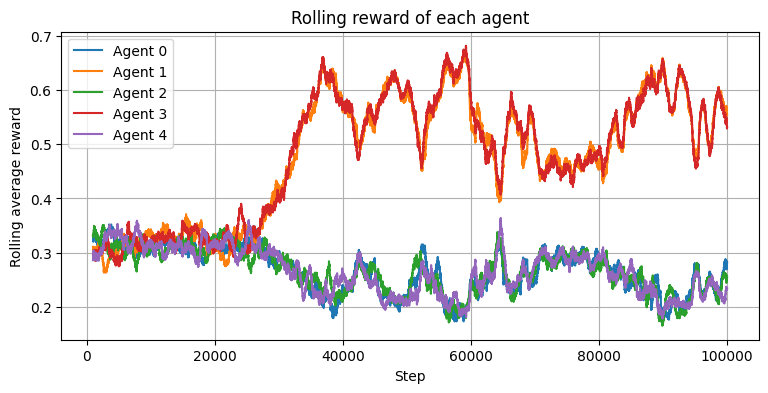

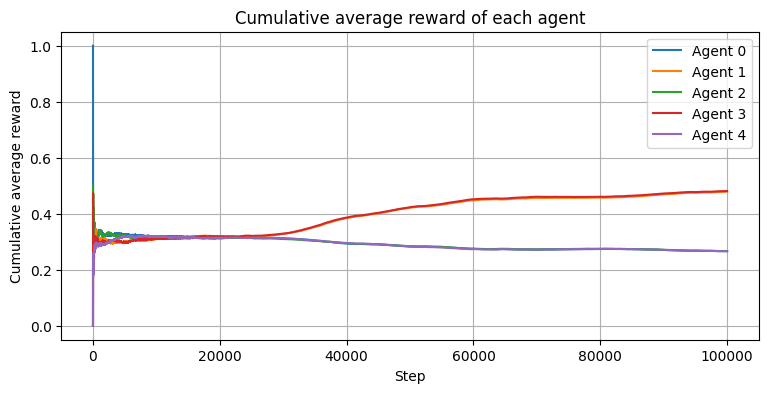

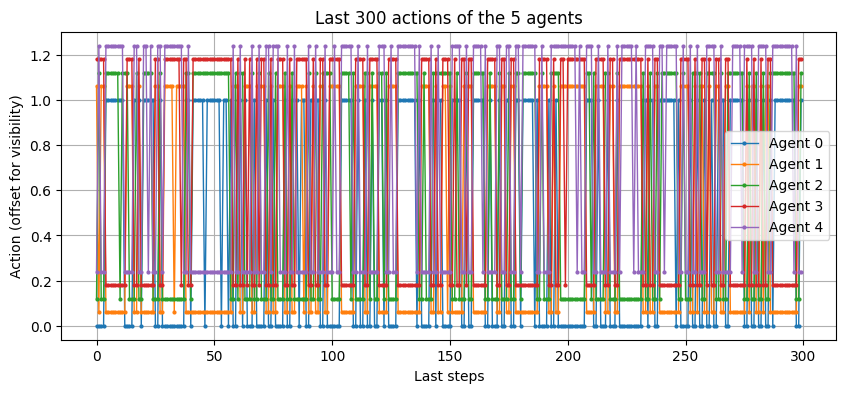

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Shared-Q Minority Game with:
#   - 5 agents
#   - shared Q-table
#   - phase information: phi_i(t) = (i + t) % phase_size
#   - reward-related state: recent reward history of each agent
#   - softmax action selection
# =========================================================


class MinorityGameSharedQPhase:
    def __init__(self, m=3, n_agents=5, reward_hist_len=2, phase_size=5, seed=0):
        assert n_agents == 5, "This version is written for 5 agents."
        self.m = int(m)
        self.n_agents = int(n_agents)
        self.reward_hist_len = int(reward_hist_len)
        self.phase_size = int(phase_size)
        self.base_states = 2 ** self.m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        # public history of minority actions
        self.public_hist = 0

        # time index
        self.t = 0

        # each agent's recent reward history, binary vector of length reward_hist_len
        # shape = (n_agents, reward_hist_len)
        self.reward_hist = np.zeros((self.n_agents, self.reward_hist_len), dtype=int)

        return self.get_states()

    def encode_binary_vec(self, vec):
        """
        Encode a binary vector into an integer.
        Example:
            [0,1] -> 1
            [1,0] -> 2
            [1,1] -> 3
        """
        x = 0
        for v in vec:
            x = (x << 1) | int(v)
        return x

    def phase_of_agent(self, i):
        """
        Rotating phase:
            phi_i(t) = (i + t) % phase_size
        """
        return (i + self.t) % self.phase_size

    def encode_state(self, public_hist, phase, reward_hist_code):
        """
        State = (public_hist, phase, reward_hist_code)

        public_hist     in [0, 2^m - 1]
        phase           in [0, phase_size - 1]
        reward_hist_code in [0, 2^reward_hist_len - 1]
        """
        return (public_hist * self.phase_size + phase) * (2 ** self.reward_hist_len) + reward_hist_code

    def get_states(self):
        states = np.zeros(self.n_agents, dtype=int)
        for i in range(self.n_agents):
            phase = self.phase_of_agent(i)
            reward_hist_code = self.encode_binary_vec(self.reward_hist[i])
            states[i] = self.encode_state(self.public_hist, phase, reward_hist_code)
        return states

    def step(self, actions):
        """
        Minority game rule:
            - minority side gets reward 1
            - majority side gets reward 0
            - with 5 agents, there is always a strict minority
        """
        actions = np.asarray(actions, dtype=int)
        assert actions.shape == (self.n_agents,)

        n0 = np.sum(actions == 0)
        n1 = np.sum(actions == 1)

        rewards = np.zeros(self.n_agents, dtype=float)

        if n0 < n1:
            minority_action = 0
            rewards[actions == 0] = 1.0
        else:
            minority_action = 1
            rewards[actions == 1] = 1.0

        # update public history with minority action
        self.public_hist = ((self.public_hist << 1) & (self.base_states - 1)) | minority_action

        # update reward histories
        rewards_int = rewards.astype(int)
        if self.reward_hist_len > 1:
            self.reward_hist[:, :-1] = self.reward_hist[:, 1:]
        self.reward_hist[:, -1] = rewards_int

        # time moves forward
        self.t += 1

        next_states = self.get_states()
        return next_states, rewards, minority_action


def softmax_action(Q, state, tau, rng):
    q = Q[state]
    q_shift = q - np.max(q)   # numerical stability
    prob = np.exp(q_shift / tau)
    prob = prob / prob.sum()
    return rng.choice([0, 1], p=prob)


def run_shared_q_phase(
    m=3,
    steps=100000,
    seed=42,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.10,
    tau_decay=0.99995,
    reward_hist_len=2,
    phase_size=5,
    log_window=1000
):
    env = MinorityGameSharedQPhase(
        m=m,
        n_agents=5,
        reward_hist_len=reward_hist_len,
        phase_size=phase_size,
        seed=seed
    )

    n_states = (2 ** m) * phase_size * (2 ** reward_hist_len)
    n_actions = 2

    # shared Q-table
    Q = np.zeros((n_states, n_actions), dtype=float)

    states = env.reset()
    tau = tau_start

    rewards_hist = np.zeros((steps, 5), dtype=float)
    actions_hist = np.zeros((steps, 5), dtype=int)
    minority_hist = np.zeros(steps, dtype=int)
    tau_hist = np.zeros(steps, dtype=float)

    for t in range(steps):
        actions = np.zeros(5, dtype=int)

        # all agents use same Q-table, but different state due to phase + own reward history
        for i in range(5):
            actions[i] = softmax_action(Q, states[i], tau, env.rng)

        next_states, rewards, minority_action = env.step(actions)

        # shared updates
        for i in range(5):
            s = states[i]
            a = actions[i]
            r = rewards[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (td_target - Q[s, a])

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = minority_action
        tau_hist[t] = tau

        states = next_states
        tau = max(tau_end, tau * tau_decay)

    # rolling average of rewards for each agent
    rolling_rewards = np.full((steps, 5), np.nan)
    if log_window <= steps:
        kernel = np.ones(log_window) / log_window
        for i in range(5):
            rolling_rewards[log_window - 1:, i] = np.convolve(
                rewards_hist[:, i], kernel, mode='valid'
            )

    return Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist


# =========================================================
# Run experiment
# =========================================================
Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist = run_shared_q_phase(
    m=3,
    steps=100000,
    seed=123,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.10,
    tau_decay=0.99995,
    reward_hist_len=3,   # try 2 first; can also test 3
    phase_size=2,
    log_window=1000
)

print("Training finished.")
print("Final tau =", tau_hist[-1])
print("Shared Q-table shape =", Q.shape)
print("Average reward per agent over all steps:")
print(rewards_hist[-5000:].mean(axis=0))
print("Overall average reward across agents:")
print(rewards_hist[-5000:].mean())


# =========================================================
# Plot 1: rolling reward of each agent
# =========================================================
plt.figure(figsize=(9, 4))
for i in range(5):
    plt.plot(rolling_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Rolling average reward")
plt.title("Rolling reward of each agent")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 2: cumulative average reward
# =========================================================
cum_avg_rewards = np.cumsum(rewards_hist, axis=0) / (np.arange(len(rewards_hist))[:, None] + 1)

plt.figure(figsize=(9, 4))
for i in range(5):
    plt.plot(cum_avg_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Cumulative average reward")
plt.title("Cumulative average reward of each agent")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 3: last 300 actions
# =========================================================
last = 300
tail_actions = actions_hist[-last:]

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.plot(np.arange(last), tail_actions[:, i] + 0.06 * i,
             marker='o', markersize=2, linewidth=1, label=f"Agent {i}")
plt.xlabel("Last steps")
plt.ylabel("Action (offset for visibility)")
plt.title("Last 300 actions of the 5 agents")
plt.legend()
plt.grid(True)
plt.show()

Training finished.
Final tau = 0.3
Shared Q-table shape = (448, 2)
Average reward per agent over all steps:
[0.4288 0.4284 0.4286 0.4288 0.4284 0.4286 0.4284]
Overall average reward across agents:
0.42857142857142855


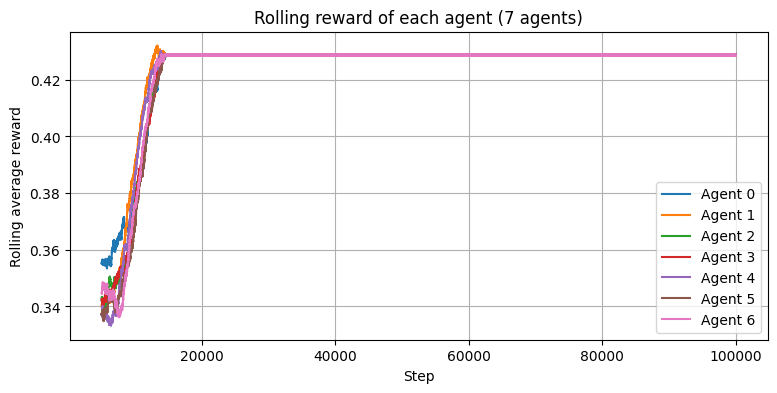

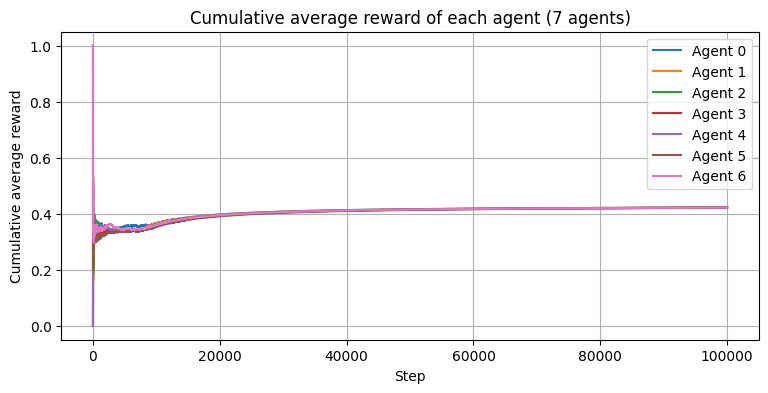

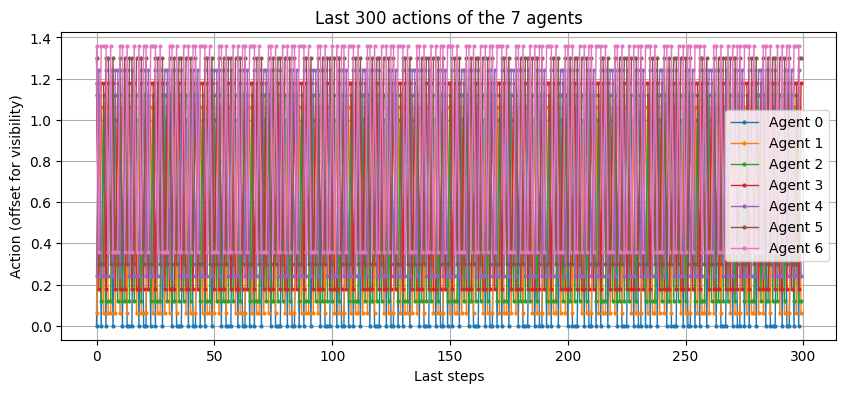

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Shared-Q Minority Game with:
#   - 7 agents
#   - shared Q-table
#   - phase information: phi_i(t) = (i + t) % phase_size
#   - reward-related state: recent reward history of each agent
#   - softmax action selection
# =========================================================


class MinorityGameSharedQPhase:
    def __init__(self, m=7, n_agents=7, reward_hist_len=2, phase_size=7, seed=0):
        assert n_agents == 7, "This version is written for 7 agents."
        self.m = int(m)
        self.n_agents = int(n_agents)
        self.reward_hist_len = int(reward_hist_len)
        self.phase_size = int(phase_size)
        self.base_states = 2 ** self.m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        # public history of minority actions
        self.public_hist = 0

        # time index
        self.t = 0

        # each agent's recent reward history, binary vector of length reward_hist_len
        self.reward_hist = np.zeros((self.n_agents, self.reward_hist_len), dtype=int)

        return self.get_states()

    def encode_binary_vec(self, vec):
        """
        Encode a binary vector into an integer.
        Example:
            [0,1] -> 1
            [1,0] -> 2
            [1,1] -> 3
        """
        x = 0
        for v in vec:
            x = (x << 1) | int(v)
        return x

    def phase_of_agent(self, i):
        """
        Rotating phase:
            phi_i(t) = (i + t) % phase_size
        """
        return (i + self.t) % self.phase_size

    def encode_state(self, public_hist, phase, reward_hist_code):
        """
        State = (public_hist, phase, reward_hist_code)

        public_hist      in [0, 2^m - 1]
        phase            in [0, phase_size - 1]
        reward_hist_code in [0, 2^reward_hist_len - 1]
        """
        return (public_hist * self.phase_size + phase) * (2 ** self.reward_hist_len) + reward_hist_code

    def get_states(self):
        states = np.zeros(self.n_agents, dtype=int)
        for i in range(self.n_agents):
            phase = self.phase_of_agent(i)
            reward_hist_code = self.encode_binary_vec(self.reward_hist[i])
            states[i] = self.encode_state(self.public_hist, phase, reward_hist_code)
        return states

    def step(self, actions):
        """
        Minority game rule:
            - minority side gets reward 1
            - majority side gets reward 0
            - since n_agents=7 is odd, there is always a strict minority
        """
        actions = np.asarray(actions, dtype=int)
        assert actions.shape == (self.n_agents,)

        n0 = np.sum(actions == 0)
        n1 = np.sum(actions == 1)

        rewards = np.zeros(self.n_agents, dtype=float)

        if n0 < n1:
            minority_action = 0
            rewards[actions == 0] = 1.0
        else:
            minority_action = 1
            rewards[actions == 1] = 1.0

        # update public history with minority action
        self.public_hist = ((self.public_hist << 1) & (self.base_states - 1)) | minority_action

        # update reward histories
        rewards_int = rewards.astype(int)
        if self.reward_hist_len > 1:
            self.reward_hist[:, :-1] = self.reward_hist[:, 1:]
        self.reward_hist[:, -1] = rewards_int

        # time moves forward
        self.t += 1

        next_states = self.get_states()
        return next_states, rewards, minority_action


def softmax_action(Q, state, tau, rng):
    q = Q[state]
    q_shift = q - np.max(q)   # numerical stability
    prob = np.exp(q_shift / tau)
    prob = prob / prob.sum()
    return rng.choice([0, 1], p=prob)


def run_shared_q_phase(
    m=7,
    steps=100000,
    seed=42,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.02,
    tau_decay=0.99995,
    reward_hist_len=2,
    phase_size=7,
    log_window=1000
):
    env = MinorityGameSharedQPhase(
        m=m,
        n_agents=7,
        reward_hist_len=reward_hist_len,
        phase_size=phase_size,
        seed=seed
    )

    n_states = (2 ** m) * phase_size * (2 ** reward_hist_len)
    n_actions = 2

    # one shared Q-table
    Q = np.zeros((n_states, n_actions), dtype=float)

    states = env.reset()
    tau = tau_start

    rewards_hist = np.zeros((steps, 7), dtype=float)
    actions_hist = np.zeros((steps, 7), dtype=int)
    minority_hist = np.zeros(steps, dtype=int)
    tau_hist = np.zeros(steps, dtype=float)

    for t in range(steps):
        actions = np.zeros(7, dtype=int)

        # all agents use the same Q-table
        for i in range(7):
            actions[i] = softmax_action(Q, states[i], tau, env.rng)

        next_states, rewards, minority_action = env.step(actions)

        # shared Q update
        for i in range(7):
            s = states[i]
            a = actions[i]
            r = rewards[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (td_target - Q[s, a])

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = minority_action
        tau_hist[t] = tau

        states = next_states
        tau = max(tau_end, tau * tau_decay)

    # rolling average reward of each agent
    rolling_rewards = np.full((steps, 7), np.nan)
    if log_window <= steps:
        kernel = np.ones(log_window) / log_window
        for i in range(7):
            rolling_rewards[log_window - 1:, i] = np.convolve(
                rewards_hist[:, i], kernel, mode='valid'
            )

    return Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist


# =========================================================
# Run experiment
# =========================================================
Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist = run_shared_q_phase(
    m=3,
    steps=100000,
    seed=123,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.3,
    tau_decay=0.9999,
    reward_hist_len=3,   # can also try 3
    phase_size=7,
    log_window=5000
)

print("Training finished.")
print("Final tau =", tau_hist[-1])
print("Shared Q-table shape =", Q.shape)
print("Average reward per agent over all steps:")
print(rewards_hist[-5000:].mean(axis=0))
print("Overall average reward across agents:")
print(rewards_hist[-5000:].mean())


# =========================================================
# Plot 1: rolling reward of each agent
# =========================================================
plt.figure(figsize=(9, 4))
for i in range(7):
    plt.plot(rolling_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Rolling average reward")
plt.title("Rolling reward of each agent (7 agents)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 2: cumulative average reward
# =========================================================
cum_avg_rewards = np.cumsum(rewards_hist, axis=0) / (np.arange(len(rewards_hist))[:, None] + 1)

plt.figure(figsize=(9, 4))
for i in range(7):
    plt.plot(cum_avg_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Cumulative average reward")
plt.title("Cumulative average reward of each agent (7 agents)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 3: last 300 actions
# =========================================================
last = 300
tail_actions = actions_hist[-last:]

plt.figure(figsize=(10, 4))
for i in range(7):
    plt.plot(np.arange(last), tail_actions[:, i] + 0.06 * i,
             marker='o', markersize=2, linewidth=1, label=f"Agent {i}")
plt.xlabel("Last steps")
plt.ylabel("Action (offset for visibility)")
plt.title("Last 300 actions of the 7 agents")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(Q[:20])
len(Q)

[[8.2063496  8.72762085]
 [4.3403165  8.49538021]
 [4.25786554 4.0704812 ]
 [4.09648747 8.49380563]
 [8.55674394 8.05867268]
 [8.26174777 5.09632456]
 [8.37923815 5.62111213]
 [2.78854167 4.1776915 ]
 [8.24430341 7.61623289]
 [8.56000474 8.36943906]
 [6.19448795 6.23195518]
 [8.53111493 2.55474786]
 [8.30045632 4.85221607]
 [8.36406474 3.32233103]
 [8.69647457 5.01571133]
 [8.50851988 2.9568527 ]
 [5.53039672 5.34440584]
 [8.25121462 8.53667852]
 [4.40532941 3.45575105]
 [3.05769838 8.55269873]]


112

In [ ]:
def decode_state(state, m=7, phase_size=7, reward_hist_len=3):
    n_reward = 2 ** reward_hist_len

    reward_hist_code = state % n_reward
    tmp = state // n_reward

    phase = tmp % phase_size
    public_hist = tmp // phase_size

    return public_hist, phase, reward_hist_code


for s in range(1000):
    public_hist, phase, reward_code = decode_state(
        s, m=7, phase_size=7, reward_hist_len=3
    )
    print(
        f"state={s:4d}, public_hist={public_hist:3d}, "
        f"phase={phase}, reward_code={reward_code}, Q={Q[s]}"
    )

state=   0, public_hist=  0, phase=0, reward_code=0, Q=[1.3118379  1.46647152]
state=   1, public_hist=  0, phase=0, reward_code=1, Q=[0.50313138 1.5027778 ]
state=   2, public_hist=  0, phase=0, reward_code=2, Q=[1.33291222 0.94500419]
state=   3, public_hist=  0, phase=0, reward_code=3, Q=[0.51238308 1.67053174]
state=   4, public_hist=  0, phase=0, reward_code=4, Q=[0.77881127 0.87493135]
state=   5, public_hist=  0, phase=0, reward_code=5, Q=[0.67599566 0.52405358]
state=   6, public_hist=  0, phase=0, reward_code=6, Q=[0.4768611 8.4143222]
state=   7, public_hist=  0, phase=0, reward_code=7, Q=[0.17336291 0.60426187]
state=   8, public_hist=  0, phase=1, reward_code=0, Q=[1.98582175 0.7476977 ]
state=   9, public_hist=  0, phase=1, reward_code=1, Q=[0.6285983 1.1353115]
state=  10, public_hist=  0, phase=1, reward_code=2, Q=[1.92022092 0.36329649]
state=  11, public_hist=  0, phase=1, reward_code=3, Q=[0.64358095 0.20115578]
state=  12, public_hist=  0, phase=1, reward_code=4, Q=[

In [ ]:
def encode_state(public_hist, phase, reward_hist_code, phase_size=7, reward_hist_len=7):
    return (public_hist * phase_size + phase) * (2 ** reward_hist_len) + reward_hist_code

public_hist = 0
reward_code = 0

for phase in range(7):
    s = encode_state(public_hist, phase, reward_code, phase_size=7, reward_hist_len=3)
    print(f"phase={phase}, state={s}, Q={Q[s]}")

phase=0, state=0, Q=[1.3118379  1.46647152]
phase=1, state=8, Q=[1.98582175 0.7476977 ]
phase=2, state=16, Q=[1.40522017 0.61051601]
phase=3, state=24, Q=[0.84243157 1.30309903]
phase=4, state=32, Q=[1.90838276 0.88639414]
phase=5, state=40, Q=[0.52571272 1.22459406]
phase=6, state=48, Q=[1.9765983  1.39073408]


Training finished.
Final tau = 0.02
Shared Q-table shape = (576, 2)
Average reward per agent over last 5000 steps:
[0.4444 0.4444 0.4444 0.4442 0.4444 0.4444 0.4446 0.4446 0.4446]
Overall average reward across agents:
0.4444444444444444


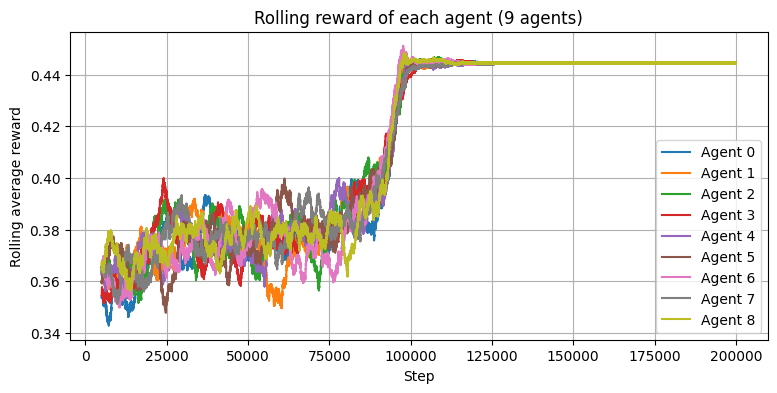

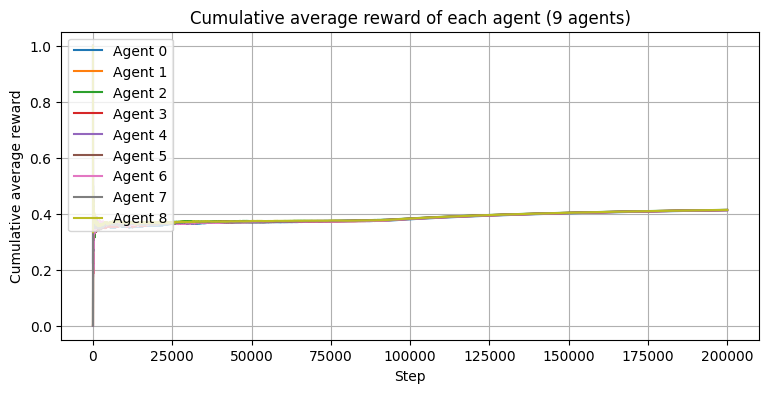

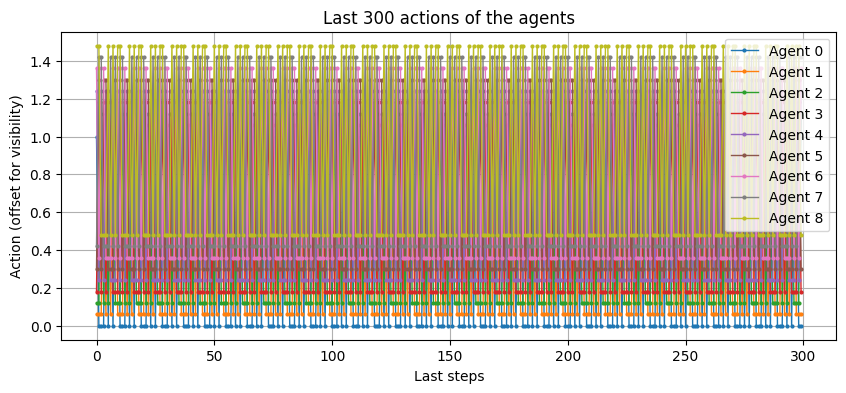

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Shared-Q Minority Game with:
#   - arbitrary number of agents
#   - shared Q-table
#   - phase information: phi_i(t) = (i + t) % phase_size
#   - reward-related state: recent reward history of each agent
#   - softmax action selection
# =========================================================


class MinorityGameSharedQPhase:
    def __init__(self, m=7, n_agents=7, reward_hist_len=2, phase_size=None, seed=0):
        self.m = int(m)
        self.n_agents = int(n_agents)
        self.reward_hist_len = int(reward_hist_len)

        # if phase_size is not given, default to n_agents
        self.phase_size = int(phase_size) if phase_size is not None else int(n_agents)

        self.base_states = 2 ** self.m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        # public history of minority actions
        self.public_hist = 0

        # time index
        self.t = 0

        # each agent's recent reward history, binary vector of length reward_hist_len
        self.reward_hist = np.zeros((self.n_agents, self.reward_hist_len), dtype=int)

        return self.get_states()

    def encode_binary_vec(self, vec):
        """
        Encode a binary vector into an integer.
        Example:
            [0,1] -> 1
            [1,0] -> 2
            [1,1] -> 3
        """
        x = 0
        for v in vec:
            x = (x << 1) | int(v)
        return x

    def phase_of_agent(self, i):
        """
        Rotating phase:
            phi_i(t) = (i + t) % phase_size
        """
        return (i + self.t) % self.phase_size

    def encode_state(self, public_hist, phase, reward_hist_code):
        """
        State = (public_hist, phase, reward_hist_code)

        public_hist      in [0, 2^m - 1]
        phase            in [0, phase_size - 1]
        reward_hist_code in [0, 2^reward_hist_len - 1]
        """
        return (public_hist * self.phase_size + phase) * (2 ** self.reward_hist_len) + reward_hist_code

    def get_states(self):
        states = np.zeros(self.n_agents, dtype=int)
        for i in range(self.n_agents):
            phase = self.phase_of_agent(i)
            reward_hist_code = self.encode_binary_vec(self.reward_hist[i])
            states[i] = self.encode_state(self.public_hist, phase, reward_hist_code)
        return states

    def step(self, actions):
        """
        Minority game rule:
            - minority side gets reward 1
            - majority side gets reward 0
            - if tie (possible when n_agents is even), all get reward 0
        """
        actions = np.asarray(actions, dtype=int)
        assert actions.shape == (self.n_agents,)

        n0 = np.sum(actions == 0)
        n1 = np.sum(actions == 1)

        rewards = np.zeros(self.n_agents, dtype=float)

        if n0 < n1:
            minority_action = 0
            rewards[actions == 0] = 1.0
        elif n1 < n0:
            minority_action = 1
            rewards[actions == 1] = 1.0
        else:
            # tie case for even number of agents
            minority_action = 0
            # all rewards remain 0

        # update public history with minority action
        self.public_hist = ((self.public_hist << 1) & (self.base_states - 1)) | minority_action

        # update reward histories
        rewards_int = rewards.astype(int)
        if self.reward_hist_len > 1:
            self.reward_hist[:, :-1] = self.reward_hist[:, 1:]
        self.reward_hist[:, -1] = rewards_int

        # time moves forward
        self.t += 1

        next_states = self.get_states()
        return next_states, rewards, minority_action


def softmax_action(Q, state, tau, rng):
    q = Q[state]
    q_shift = q - np.max(q)   # numerical stability
    prob = np.exp(q_shift / tau)
    prob = prob / prob.sum()
    return rng.choice([0, 1], p=prob)


def run_shared_q_phase(
    m=7,
    n_agents=7,
    steps=250000,
    seed=42,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.02,
    tau_decay=0.99995,
    reward_hist_len=2,
    phase_size=None,
    log_window=1000
):
    env = MinorityGameSharedQPhase(
        m=m,
        n_agents=n_agents,
        reward_hist_len=reward_hist_len,
        phase_size=phase_size,
        seed=seed
    )

    n_states = (2 ** m) * env.phase_size * (2 ** reward_hist_len)
    n_actions = 2

    # one shared Q-table
    Q = np.zeros((n_states, n_actions), dtype=float)

    states = env.reset()
    tau = tau_start

    rewards_hist = np.zeros((steps, n_agents), dtype=float)
    actions_hist = np.zeros((steps, n_agents), dtype=int)
    minority_hist = np.zeros(steps, dtype=int)
    tau_hist = np.zeros(steps, dtype=float)

    for t in range(steps):
        actions = np.zeros(n_agents, dtype=int)

        # all agents use the same Q-table
        for i in range(n_agents):
            actions[i] = softmax_action(Q, states[i], tau, env.rng)

        next_states, rewards, minority_action = env.step(actions)

        # shared Q update
        for i in range(n_agents):
            s = states[i]
            a = actions[i]
            r = rewards[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (td_target - Q[s, a])

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = minority_action
        tau_hist[t] = tau

        states = next_states
        tau = max(tau_end, tau * tau_decay)

    # rolling average reward of each agent
    rolling_rewards = np.full((steps, n_agents), np.nan)
    if log_window <= steps:
        kernel = np.ones(log_window) / log_window
        for i in range(n_agents):
            rolling_rewards[log_window - 1:, i] = np.convolve(
                rewards_hist[:, i], kernel, mode='valid'
            )

    return Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist


# =========================================================
# Run experiment
# =========================================================
Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist = run_shared_q_phase(
    m=3,
    n_agents=9,          # <- now you can change this freely
    steps=200000,
    seed=123,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.02,
    tau_decay=0.99998,
    reward_hist_len=3,
    phase_size=9,        # usually you may set this equal to n_agents
    log_window=5000
)

print("Training finished.")
print("Final tau =", tau_hist[-1])
print("Shared Q-table shape =", Q.shape)
print("Average reward per agent over last 5000 steps:")
print(rewards_hist[-5000:].mean(axis=0))
print("Overall average reward across agents:")
print(rewards_hist[-5000:].mean())


# =========================================================
# Plot 1: rolling reward of each agent
# =========================================================
plt.figure(figsize=(9, 4))
for i in range(rewards_hist.shape[1]):
    plt.plot(rolling_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Rolling average reward")
plt.title(f"Rolling reward of each agent ({rewards_hist.shape[1]} agents)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 2: cumulative average reward
# =========================================================
cum_avg_rewards = np.cumsum(rewards_hist, axis=0) / (np.arange(len(rewards_hist))[:, None] + 1)

plt.figure(figsize=(9, 4))
for i in range(rewards_hist.shape[1]):
    plt.plot(cum_avg_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Cumulative average reward")
plt.title(f"Cumulative average reward of each agent ({rewards_hist.shape[1]} agents)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 3: last 300 actions
# =========================================================
last = 300
tail_actions = actions_hist[-last:]

plt.figure(figsize=(10, 4))
for i in range(tail_actions.shape[1]):
    plt.plot(
        np.arange(last),
        tail_actions[:, i] + 0.06 * i,
        marker='o',
        markersize=2,
        linewidth=1,
        label=f"Agent {i}"
    )
plt.xlabel("Last steps")
plt.ylabel("Action (offset for visibility)")
plt.title(f"Last {last} actions of the agents")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def rolling_mean(x, window=1000):
    """
    Compute rolling mean for a 1D array.
    """
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return np.array([])
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def choose_action_shared(Q, state, epsilon, rng):
    """
    Epsilon-greedy action selection from a shared Q-table.
    No phase signal is used here.
    """
    if rng.random() < epsilon:
        return rng.integers(0, 2)

    q_values = Q[state]
    max_q = np.max(q_values)
    best_actions = np.flatnonzero(q_values == max_q)
    return rng.choice(best_actions)


def train_shared_q_no_phase(
    N=7,
    m=5,
    T=80000,
    alpha=0.1,
    gamma=0.95,
    eps_start=1.0,
    eps_end=0.001,
    eps_decay=0.99995,
    seed=0
):
    """
    Shared Q-learning baseline without phase signal.

    State:
        h_t: public history of the last m minority outcomes.

    Q-table:
        Q[h, a], shared by all agents.

    Important:
        There is no agent identity or phase information in the state.
        Therefore, all agents use the same policy pi(a | h).
    """
    assert N % 2 == 1, "N should be odd for the standard Minority Game."

    rng = np.random.default_rng(seed)

    num_states = 2 ** m
    num_actions = 2
    Q = np.zeros((num_states, num_actions))

    # Random initial public history
    state = rng.integers(0, num_states)
    mask = num_states - 1

    rewards = np.zeros((T, N))
    actions_record = np.zeros((T, N), dtype=int)
    minority_record = np.zeros(T, dtype=int)
    total_reward_record = np.zeros(T)
    winner_record = []

    for t in range(T):
        epsilon = max(eps_end, eps_start * (eps_decay ** t))

        # All agents observe the same public state and use the same shared Q-table
        actions = np.array([
            choose_action_shared(Q, state, epsilon, rng)
            for _ in range(N)
        ])

        num_ones = np.sum(actions)
        num_zeros = N - num_ones

        # Minority action
        if num_ones < num_zeros:
            minority_action = 1
        else:
            minority_action = 0

        # Payoff: agents choosing minority action receive 1
        r = (actions == minority_action).astype(float)

        # Update public history state
        next_state = ((state << 1) & mask) | minority_action

        # Shared Q-table update.
        # Each agent contributes one transition sample to the same Q-table.
        for i in range(N):
            a_i = actions[i]
            r_i = r[i]
            td_target = r_i + gamma * np.max(Q[next_state])
            td_error = td_target - Q[state, a_i]
            Q[state, a_i] += alpha * td_error

        rewards[t] = r
        actions_record[t] = actions
        minority_record[t] = minority_action
        total_reward_record[t] = np.sum(r)

        winners = np.flatnonzero(r == 1)
        winner_record.append(winners)

        state = next_state

    result = {
        "Q": Q,
        "rewards": rewards,
        "actions": actions_record,
        "minority": minority_record,
        "total_reward": total_reward_record,
        "winners": winner_record,
        "params": {
            "N": N,
            "m": m,
            "T": T,
            "alpha": alpha,
            "gamma": gamma,
            "eps_start": eps_start,
            "eps_end": eps_end,
            "eps_decay": eps_decay,
            "seed": seed
        }
    }

    return result


def plot_individual_rolling_rewards(result, window=1000, title=None):
    """
    Plot rolling average reward of each agent.
    """
    rewards = result["rewards"]
    N = result["params"]["N"]
    T = result["params"]["T"]

    plt.figure(figsize=(10, 4))

    for i in range(N):
        rm = rolling_mean(rewards[:, i], window=window)
        x = np.arange(window - 1, T)
        plt.plot(x, rm, label=f"Agent {i}")

    U_max = (N - 1) / 2
    fair_value = U_max / N

    plt.axhline(
        fair_value,
        linestyle="--",
        linewidth=1.2,
        label=f"Fair value = {fair_value:.4f}"
    )

    if title is None:
        title = f"Rolling reward of each agent, no phase signal, N={N}"

    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Rolling average reward")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_total_reward(result, window=1000, title=None):
    """
    Plot rolling total reward.
    """
    total_reward = result["total_reward"]
    N = result["params"]["N"]
    T = result["params"]["T"]

    rm = rolling_mean(total_reward, window=window)
    x = np.arange(window - 1, T)

    U_max = (N - 1) / 2

    plt.figure(figsize=(10, 4))
    plt.plot(x, rm, label="Rolling total reward")
    plt.axhline(
        U_max,
        linestyle="--",
        linewidth=1.2,
        label=f"Global optimum = {U_max:.0f}"
    )

    if title is None:
        title = f"Rolling total reward, no phase signal, N={N}"

    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Rolling total reward")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_final_action_pattern(result, last_steps=50):
    """
    Visualize the final learned action pattern.
    Rows are agents and columns are time steps.
    """
    actions = result["actions"]
    N = result["params"]["N"]
    T = result["params"]["T"]

    final_actions = actions[T - last_steps:T].T

    plt.figure(figsize=(12, 3))
    plt.imshow(final_actions, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Action")
    plt.yticks(np.arange(N), [f"Agent {i}" for i in range(N)])
    plt.xlabel("Final training steps")
    plt.ylabel("Agent")
    plt.title(f"Final action pattern without phase signal, last {last_steps} steps")
    plt.tight_layout()
    plt.show()


def plot_final_winner_pattern(result, last_steps=50):
    """
    Visualize which agents win in the final stage.
    1 means the agent receives reward, 0 means the agent loses.
    """
    rewards = result["rewards"]
    N = result["params"]["N"]
    T = result["params"]["T"]

    final_rewards = rewards[T - last_steps:T].T

    plt.figure(figsize=(12, 3))
    plt.imshow(final_rewards, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Reward")
    plt.yticks(np.arange(N), [f"Agent {i}" for i in range(N)])
    plt.xlabel("Final training steps")
    plt.ylabel("Agent")
    plt.title(f"Final winner pattern without phase signal, last {last_steps} steps")
    plt.tight_layout()
    plt.show()


def summarize_result(result, last_fraction=0.25):
    """
    Print final efficiency and fairness statistics.
    """
    rewards = result["rewards"]
    total_reward = result["total_reward"]
    N = result["params"]["N"]
    T = result["params"]["T"]

    start = int((1 - last_fraction) * T)

    final_agent_rewards = rewards[start:].mean(axis=0)
    final_total_reward = total_reward[start:].mean()

    U_max = (N - 1) / 2
    fair_value = U_max / N

    print("========== Summary ==========")
    print(f"N = {N}")
    print(f"Global optimum U_max = {U_max:.4f}")
    print(f"Theoretical fair payoff per agent = {fair_value:.4f}")
    print()
    print(f"Final average total reward = {final_total_reward:.4f}")
    print(f"Efficiency ratio = {final_total_reward / U_max:.4f}")
    print()
    print("Final average reward per agent:")
    for i, val in enumerate(final_agent_rewards):
        print(f"Agent {i}: {val:.4f}")
    print()
    print(f"Fairness std across agents = {np.std(final_agent_rewards):.6f}")
    print("=============================")

Running seed=0, N=5, m=3, r=3, phase=5
Running seed=1, N=5, m=3, r=3, phase=5
Running seed=2, N=5, m=3, r=3, phase=5
Running seed=3, N=5, m=3, r=3, phase=5
Running seed=4, N=5, m=3, r=3, phase=5
Running seed=0, N=7, m=3, r=3, phase=7
Running seed=1, N=7, m=3, r=3, phase=7
Running seed=2, N=7, m=3, r=3, phase=7
Running seed=3, N=7, m=3, r=3, phase=7
Running seed=4, N=7, m=3, r=3, phase=7
Running seed=0, N=9, m=4, r=4, phase=9
Running seed=1, N=9, m=4, r=4, phase=9
Running seed=2, N=9, m=4, r=4, phase=9
Running seed=3, N=9, m=4, r=4, phase=9
Running seed=4, N=9, m=4, r=4, phase=9
Running seed=0, N=11, m=4, r=4, phase=11
Running seed=1, N=11, m=4, r=4, phase=11
Running seed=2, N=11, m=4, r=4, phase=11
Running seed=3, N=11, m=4, r=4, phase=11
Running seed=4, N=11, m=4, r=4, phase=11

================ RAW RESULTS ================

    seed   N  public_history_len  private_history_len  phase_size       T  \
0      0   5                   3                    3           5  100000   
1      1

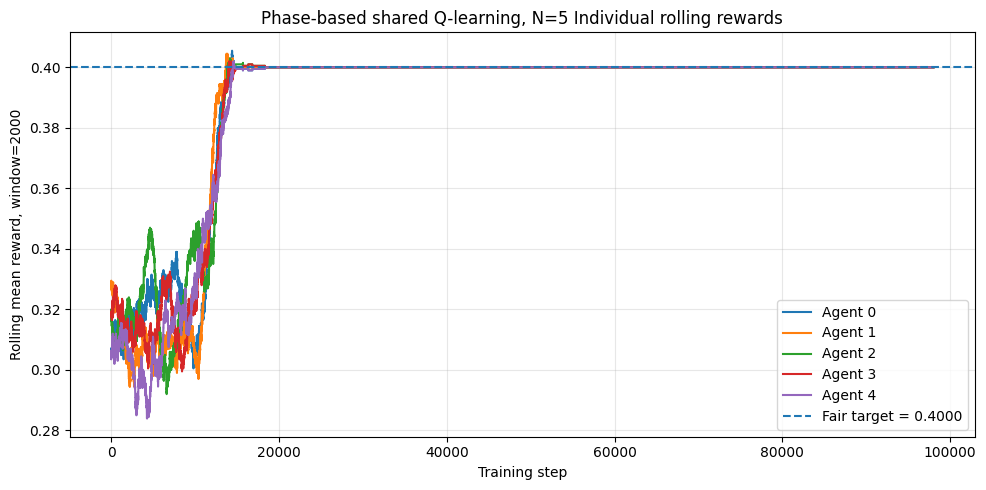

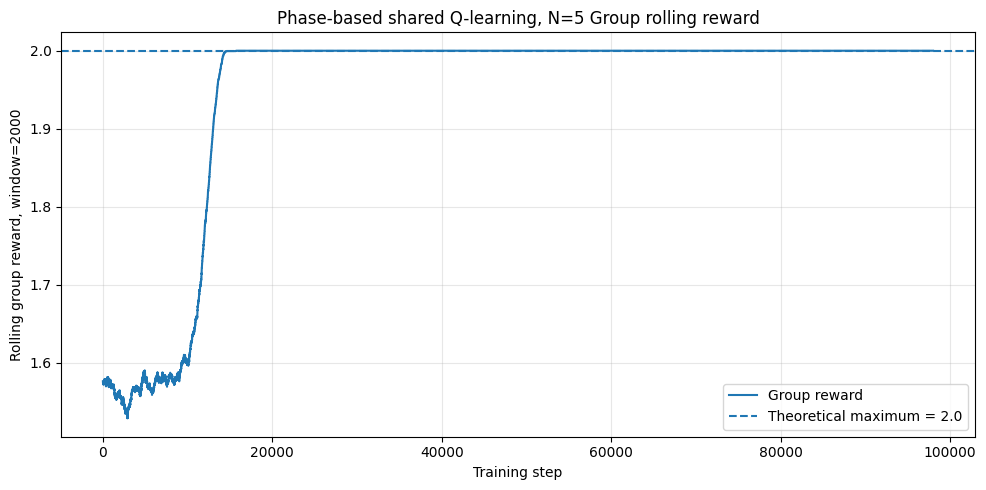

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, replace
from typing import Optional, Tuple, List


# ============================================================
# 1. Experiment Configuration
# ============================================================

@dataclass
class ExpConfig:
    # Main model parameters
    N: int = 5                              # number of agents, should be odd
    public_history_len: int = 3             # m
    private_history_len: int = 3            # r
    phase_size: Optional[int] = None        # |Phi|. If None, use phase_size = N

    # Training parameters
    T: int = 200_000
    alpha: float = 0.08
    gamma: float = 0.95

    # Softmax exploration parameters
    tau_start: float = 1.0
    tau_min: float = 0.03
    tau_decay: float = 0.99995

    # Evaluation parameters
    final_window: int = 20_000
    group_tol: float = 0.03                 # tolerance for optimality gap
    fairness_tol: float = 0.05              # tolerance for max-min payoff gap

    # Density report thresholds
    density_thresholds: Tuple[float, ...] = (0.01, 0.1, 1.0)


# ============================================================
# 2. Helper Functions
# ============================================================

def append_bit(code: int, bit: int, length: int) -> int:
    """
    Append one binary bit to a fixed-length binary history code.
    Example: if length=3, code represents last 3 bits.
    """
    if length <= 0:
        return 0
    mask = (1 << length) - 1
    return ((code << 1) | int(bit)) & mask


def sample_softmax(q_values: np.ndarray, tau: float, rng: np.random.Generator) -> int:
    """
    Sample action from softmax(Q / tau).
    If tau is extremely small, use greedy action with random tie-breaking.
    """
    if tau <= 1e-10:
        max_q = np.max(q_values)
        candidates = np.flatnonzero(np.isclose(q_values, max_q))
        return int(rng.choice(candidates))

    z = (q_values - np.max(q_values)) / tau
    probs = np.exp(z)
    probs = probs / probs.sum()
    return int(rng.choice(len(q_values), p=probs))


def rolling_mean(x: np.ndarray, window: int) -> np.ndarray:
    """
    Standard rolling mean using convolution.
    """
    if len(x) < window:
        return np.array([])
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


# ============================================================
# 3. One Seed Training Function
# ============================================================

def run_one_seed(cfg: ExpConfig, seed: int, return_trace: bool = False):
    """
    Run phase-based shared Q-learning for one random seed.

    Q-table structure:
        Q[public_history_code, phase, private_reward_code, action]

    State for agent i:
        s_i(t) = (h_pub(t), phi_i(t), h_priv_i(t))

    where:
        phi_i(t) = (i + t) mod phase_size
    """

    assert cfg.N % 2 == 1, "N should be odd in the Minority Game."

    rng = np.random.default_rng(seed)

    N = cfg.N
    m = cfg.public_history_len
    r = cfg.private_history_len
    P = cfg.phase_size if cfg.phase_size is not None else N

    public_state_size = 2 ** m if m > 0 else 1
    private_state_size = 2 ** r if r > 0 else 1
    action_size = 2

    # Shared Q-table:
    # Q[h_pub, phase, h_priv, action]
    Q = np.zeros((public_state_size, P, private_state_size, action_size), dtype=np.float64)

    # Visit counts for density / recurrent-state analysis
    state_visits = np.zeros((public_state_size, P, private_state_size), dtype=np.int64)
    action_visits = np.zeros_like(Q, dtype=np.int64)

    # Initial histories
    public_code = 0
    private_codes = np.zeros(N, dtype=np.int64)

    tau = cfg.tau_start

    group_rewards = np.zeros(cfg.T, dtype=np.float64)
    individual_rewards = np.zeros((cfg.T, N), dtype=np.int8)

    for t in range(cfg.T):

        # Each agent has a phase
        phases = (np.arange(N) + t) % P

        states = []
        actions = np.zeros(N, dtype=np.int8)

        # -----------------------------
        # Action selection
        # -----------------------------
        for i in range(N):
            s_i = (public_code, int(phases[i]), int(private_codes[i]))
            states.append(s_i)

            state_visits[s_i] += 1

            q_values = Q[s_i]
            a_i = sample_softmax(q_values, tau, rng)

            actions[i] = a_i
            action_visits[s_i + (a_i,)] += 1

        # -----------------------------
        # Minority Game reward
        # -----------------------------
        count_ones = np.sum(actions == 1)
        count_zeros = N - count_ones

        if count_ones < count_zeros:
            minority_action = 1
        else:
            minority_action = 0

        rewards = (actions == minority_action).astype(np.int8)

        group_rewards[t] = rewards.sum()
        individual_rewards[t, :] = rewards

        # -----------------------------
        # Next states
        # -----------------------------
        next_public_code = append_bit(public_code, minority_action, m)

        next_private_codes = np.zeros(N, dtype=np.int64)
        for i in range(N):
            next_private_codes[i] = append_bit(private_codes[i], rewards[i], r)

        next_phases = (np.arange(N) + t + 1) % P

        # -----------------------------
        # Shared Q-table update
        # Each agent contributes one TD update to the same Q-table.
        # -----------------------------
        for i in range(N):
            s_i = states[i]
            a_i = int(actions[i])

            next_s_i = (
                int(next_public_code),
                int(next_phases[i]),
                int(next_private_codes[i])
            )

            td_target = rewards[i] + cfg.gamma * np.max(Q[next_s_i])
            td_error = td_target - Q[s_i + (a_i,)]

            Q[s_i + (a_i,)] += cfg.alpha * td_error

        # Move to next time step
        public_code = next_public_code
        private_codes = next_private_codes

        # Temperature decay
        tau = max(cfg.tau_min, tau * cfg.tau_decay)

    # ============================================================
    # Evaluation
    # ============================================================

    final_window = min(cfg.final_window, cfg.T)

    final_group_reward = group_rewards[-final_window:].mean()
    final_individual_rewards = individual_rewards[-final_window:, :].mean(axis=0)

    U_max = (N - 1) / 2
    fair_target = U_max / N

    payoff_std = np.std(final_individual_rewards)
    max_min_gap = np.max(final_individual_rewards) - np.min(final_individual_rewards)
    optimality_gap = U_max - final_group_reward

    success = (optimality_gap <= cfg.group_tol) and (max_min_gap <= cfg.fairness_tol)

    result = {
        "seed": seed,
        "N": N,
        "public_history_len": m,
        "private_history_len": r,
        "phase_size": P,
        "T": cfg.T,
        "final_window": final_window,
        "U_max": U_max,
        "fair_target": fair_target,
        "final_group_reward": final_group_reward,
        "optimality_gap": optimality_gap,
        "payoff_std": payoff_std,
        "max_min_gap": max_min_gap,
        "success": success,
        "visited_state_ratio": np.mean(state_visits > 0),
        "visited_q_entry_ratio": np.mean(action_visits > 0),
    }

    # Individual final rewards
    for i in range(N):
        result[f"agent_{i}_reward"] = final_individual_rewards[i]

    # Q-table density
    for eps in cfg.density_thresholds:
        result[f"density_absQ_gt_{eps}"] = np.mean(np.abs(Q) > eps)

    if return_trace:
        trace = {
            "Q": Q,
            "state_visits": state_visits,
            "action_visits": action_visits,
            "group_rewards": group_rewards,
            "individual_rewards": individual_rewards,
            "final_individual_rewards": final_individual_rewards,
        }
        return result, trace

    return result


# ============================================================
# 4. Multiple Seeds
# ============================================================

def run_many_seeds(cfg: ExpConfig, seeds: List[int]) -> pd.DataFrame:
    """
    Run the same configuration under many random seeds.
    """
    rows = []

    for seed in seeds:
        print(
            f"Running seed={seed}, "
            f"N={cfg.N}, m={cfg.public_history_len}, "
            f"r={cfg.private_history_len}, phase={cfg.phase_size if cfg.phase_size is not None else cfg.N}"
        )

        row = run_one_seed(cfg, seed=seed, return_trace=False)
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize multi-seed results for each configuration.
    """
    group_cols = [
        "N",
        "public_history_len",
        "private_history_len",
        "phase_size",
        "T",
        "final_window",
    ]

    agg_dict = {
        "seed": "count",
        "success": "mean",
        "final_group_reward": ["mean", "std"],
        "optimality_gap": ["mean", "std"],
        "payoff_std": ["mean", "std"],
        "max_min_gap": ["mean", "std"],
        "visited_state_ratio": ["mean", "std"],
        "visited_q_entry_ratio": ["mean", "std"],
    }

    density_cols = [c for c in df.columns if c.startswith("density_absQ_gt_")]
    for c in density_cols:
        agg_dict[c] = ["mean", "std"]

    summary = df.groupby(group_cols).agg(agg_dict)

    # Flatten multi-index columns
    summary.columns = [
        "_".join(col).strip("_") for col in summary.columns.to_flat_index()
    ]

    summary = summary.rename(columns={
        "seed_count": "num_seeds",
        "success_mean": "success_rate",
    })

    return summary.reset_index()


# ============================================================
# 5. Plotting for One Detailed Run
# ============================================================

def plot_trace(trace, cfg: ExpConfig, window: int = 2000, title_prefix: str = ""):
    """
    Plot rolling individual rewards and rolling group reward for one seed.
    """

    individual_rewards = trace["individual_rewards"]
    group_rewards = trace["group_rewards"]

    N = cfg.N
    U_max = (N - 1) / 2
    fair_target = U_max / N

    # -----------------------------
    # Plot individual rolling rewards
    # -----------------------------
    plt.figure(figsize=(10, 5))

    for i in range(N):
        y = rolling_mean(individual_rewards[:, i], window)
        plt.plot(y, label=f"Agent {i}")

    plt.axhline(fair_target, linestyle="--", linewidth=1.5, label=f"Fair target = {fair_target:.4f}")

    plt.xlabel("Training step")
    plt.ylabel(f"Rolling mean reward, window={window}")
    plt.title(f"{title_prefix} Individual rolling rewards")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot group rolling reward
    # -----------------------------
    plt.figure(figsize=(10, 5))

    y_group = rolling_mean(group_rewards, window)
    plt.plot(y_group, label="Group reward")
    plt.axhline(U_max, linestyle="--", linewidth=1.5, label=f"Theoretical maximum = {U_max:.1f}")

    plt.xlabel("Training step")
    plt.ylabel(f"Rolling group reward, window={window}")
    plt.title(f"{title_prefix} Group rolling reward")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Example Usage
# ============================================================

# You can change these seeds.
SEEDS = list(range(5))

# Base setting.
# You can change T, alpha, gamma, tau_decay, etc. here.
BASE = ExpConfig(
    T=100_000,
    alpha=0.08,
    gamma=0.95,
    tau_start=1.0,
    tau_min=0.03,
    tau_decay=0.99995,
    final_window=20_000,
    group_tol=0.03,
    fairness_tol=0.05,
)

# ------------------------------------------------------------
# Configurations to test
# ------------------------------------------------------------
# phase_size = N means matched phase.
# phase_size = 1 means no useful phase signal.
# private_history_len = 0 means no private reward history.
#
# Recommended:
# 1. matched phase: phase_size = N
# 2. enlarged phase: phase_size > N
# 3. no-phase control: phase_size = 1
# ------------------------------------------------------------

CONFIGS = [
    # Main results
    replace(BASE, N=5, public_history_len=3, private_history_len=3, phase_size=5),
    replace(BASE, N=7, public_history_len=3, private_history_len=3, phase_size=7),

    # Enlarged phase comparison
    replace(BASE, N=9, public_history_len=4, private_history_len=4, phase_size=9),

    # No-phase control.
    # This is the strongest ablation: only public history is used.
    replace(BASE, N=11, public_history_len=4, private_history_len=4, phase_size=11),
]

# Run all configurations
all_raw_results = []

for cfg in CONFIGS:
    df_cfg = run_many_seeds(cfg, SEEDS)
    all_raw_results.append(df_cfg)

raw_results = pd.concat(all_raw_results, ignore_index=True)
summary_results = summarize_results(raw_results)

print("\n================ RAW RESULTS ================\n")
print(raw_results)

print("\n================ SUMMARY RESULTS ================\n")
print(summary_results)

# Save results
raw_results.to_csv("phase_shared_q_multiseed_raw_results.csv", index=False)
summary_results.to_csv("phase_shared_q_multiseed_summary_results.csv", index=False)

print("\nSaved:")
print("phase_shared_q_multiseed_raw_results.csv")
print("phase_shared_q_multiseed_summary_results.csv")


# ============================================================
# 7. Plot One Example Run
# ============================================================

# Choose one configuration and one seed for visualization.
demo_cfg = replace(BASE, N=5, public_history_len=3, private_history_len=3, phase_size=5)

demo_result, demo_trace = run_one_seed(demo_cfg, seed=0, return_trace=True)

print("\n================ DEMO RESULT ================\n")
print(pd.Series(demo_result))

plot_trace(
    demo_trace,
    demo_cfg,
    window=2000,
    title_prefix="Phase-based shared Q-learning, N=5"
)

Running seed=0, N=9, m=4, r=4, phase=9
Running seed=1, N=9, m=4, r=4, phase=9
Running seed=2, N=9, m=4, r=4, phase=9
Running seed=3, N=9, m=4, r=4, phase=9
Running seed=4, N=9, m=4, r=4, phase=9

================ RAW RESULTS ================

   seed  N  public_history_len  private_history_len  phase_size       T  \
0     0  9                   4                    4           9  200000   
1     1  9                   4                    4           9  200000   
2     2  9                   4                    4           9  200000   
3     3  9                   4                    4           9  200000   
4     4  9                   4                    4           9  200000   

   final_window  U_max  fair_target  final_group_reward  ...  agent_2_reward  \
0          2000    4.0     0.444444               4.000  ...          0.4440   
1          2000    4.0     0.444444               4.000  ...          0.4445   
2          2000    4.0     0.444444               3.875  ...      

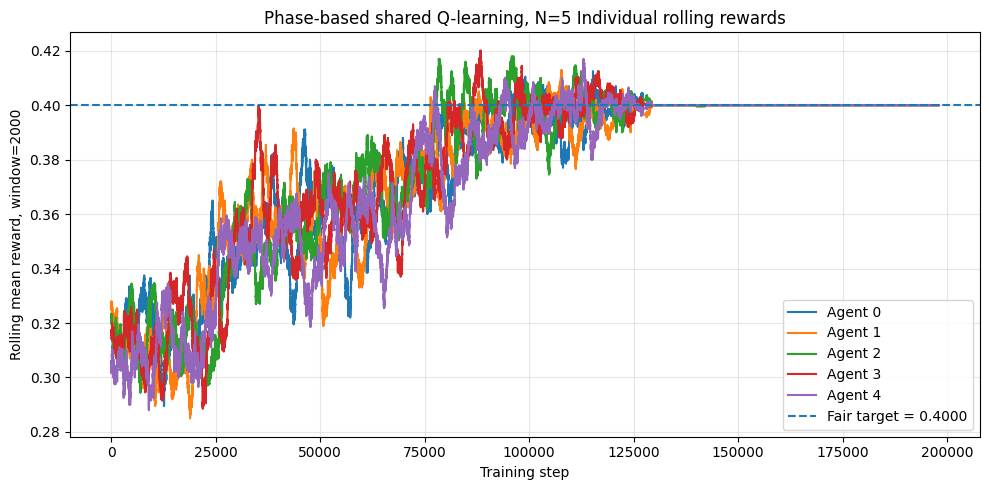

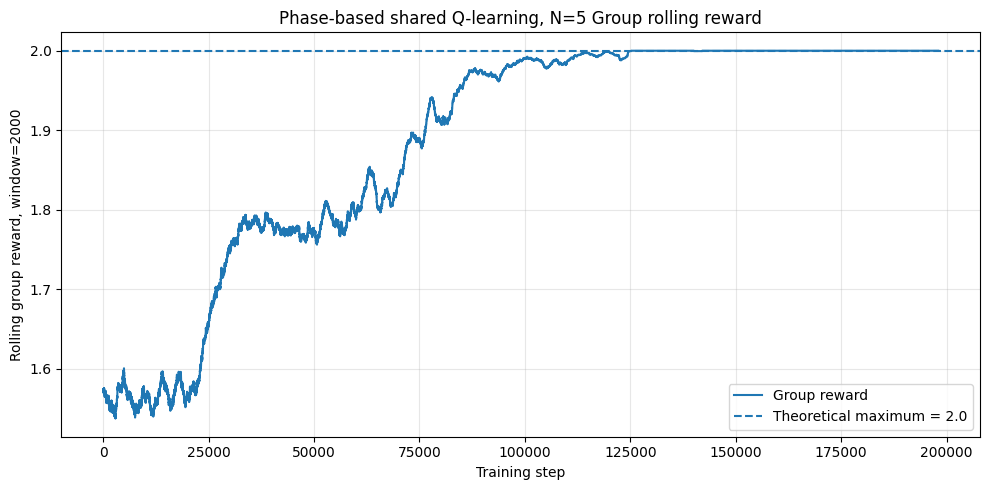

In [ ]:
BASE = ExpConfig(
    T=200_000,
    alpha=0.08,
    gamma=0.95,
    tau_start=1.0,
    tau_min=0.03,
    tau_decay=0.99998,
    final_window=2_000,
    group_tol=0.03,
    fairness_tol=0.05,
)
CONFIGS = [
    # Main results
    #replace(BASE, N=5, public_history_len=3, private_history_len=3, phase_size=5),
    #replace(BASE, N=7, public_history_len=3, private_history_len=3, phase_size=7),

    # Enlarged phase comparison
    replace(BASE, N=9, public_history_len=4, private_history_len=4, phase_size=9),

    # No-phase control.
    # This is the strongest ablation: only public history is used.
    #replace(BASE, N=11, public_history_len=4, private_history_len=4, phase_size=11),
]

# Run all configurations
all_raw_results = []

for cfg in CONFIGS:
    df_cfg = run_many_seeds(cfg, SEEDS)
    all_raw_results.append(df_cfg)

raw_results = pd.concat(all_raw_results, ignore_index=True)
summary_results = summarize_results(raw_results)

print("\n================ RAW RESULTS ================\n")
print(raw_results)

print("\n================ SUMMARY RESULTS ================\n")
print(summary_results)

# Save results
raw_results.to_csv("phase_shared_q_multiseed_raw_results.csv", index=False)
summary_results.to_csv("phase_shared_q_multiseed_summary_results.csv", index=False)

print("\nSaved:")
print("phase_shared_q_multiseed_raw_results.csv")
print("phase_shared_q_multiseed_summary_results.csv")


# ============================================================
# 7. Plot One Example Run
# ============================================================

# Choose one configuration and one seed for visualization.
demo_cfg = replace(BASE, N=5, public_history_len=3, private_history_len=3, phase_size=5)

demo_result, demo_trace = run_one_seed(demo_cfg, seed=0, return_trace=True)

print("\n================ DEMO RESULT ================\n")
print(pd.Series(demo_result))

plot_trace(
    demo_trace,
    demo_cfg,
    window=2000,
    title_prefix="Phase-based shared Q-learning, N=5"
)